In [5]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
DATASET_DIR = "../dataset_stage1"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25 #should be 21

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [16]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

In [17]:
train_ds = image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(preprocess_input(x)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = image_dataset_from_directory(
    os.path.join(DATASET_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = image_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

Found 1600 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Load pretrained MobileNetV3

In [19]:
base_model = MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

Add classification head

In [20]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

Compile model

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [22]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation_20[0]… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu_19[0][0]    │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation_20[0]… │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_20[0][0]    │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [23]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint("model/stage1_mobilenetv3.keras", monitor="val_loss", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 954ms/step - accuracy: 0.6631 - loss: 0.6622 - precision_1: 0.6667 - recall_1: 0.6525 - val_accuracy: 0.7900 - val_loss: 0.4734 - val_precision_1: 0.7685 - val_recall_1: 0.8300 - learning_rate: 0.0010
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 828ms/step - accuracy: 0.7919 - loss: 0.4274 - precision_1: 0.7937 - recall_1: 0.7887 - val_accuracy: 0.8550 - val_loss: 0.3865 - val_precision_1: 0.8318 - val_recall_1: 0.8900 - learning_rate: 0.0010
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 784ms/step - accuracy: 0.8400 - loss: 0.3633 - precision_1: 0.8192 - recall_1: 0.8725 - val_accuracy: 0.8750 - val_loss: 0.3356 - val_precision_1: 0.8641 - val_recall_1: 0.8900 - learning_rate: 0.0010
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 683ms/step - accuracy: 0.8562 - loss: 0.3271 - precision_1: 0.8484 - recall_1: 0.8675 - val_accuracy: 0.8750 - val_loss: 0.3085 - val_precision_1: 0.8505 - val_recall_1: 0.9100 - learning_rate: 0.0010
Epoch 5/25
50/50 ━━━━━━━━━━━

In [24]:
# Fine-tune top layers of the base model
base_model.trainable = True

# Optionally freeze the bottom layers to avoid overfitting
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 937ms/step - accuracy: 0.9187 - loss: 0.2070 - precision_2: 0.9209 - recall_2: 0.9162 - val_accuracy: 0.9200 - val_loss: 0.1906 - val_precision_2: 0.9118 - val_recall_2: 0.9300
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 715ms/step - accuracy: 0.9244 - loss: 0.2000 - precision_2: 0.9249 - recall_2: 0.9237 - val_accuracy: 0.9200 - val_loss: 0.1921 - val_precision_2: 0.9118 - val_recall_2: 0.9300
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 741ms/step - accuracy: 0.9206 - loss: 0.1958 - precision_2: 0.9276 - recall_2: 0.9125 - val_accuracy: 0.9150 - val_loss: 0.1933 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 734ms/step - accuracy: 0.9312 - loss: 0.1768 - precision_2: 0.9323 - recall_2: 0.9300 - val_accuracy: 0.9150 - val_loss: 0.1936 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 738ms/step - accuracy: 0.9325 - loss: 0.1868 - precision_2: 0.9240 - recall_2: 0.9

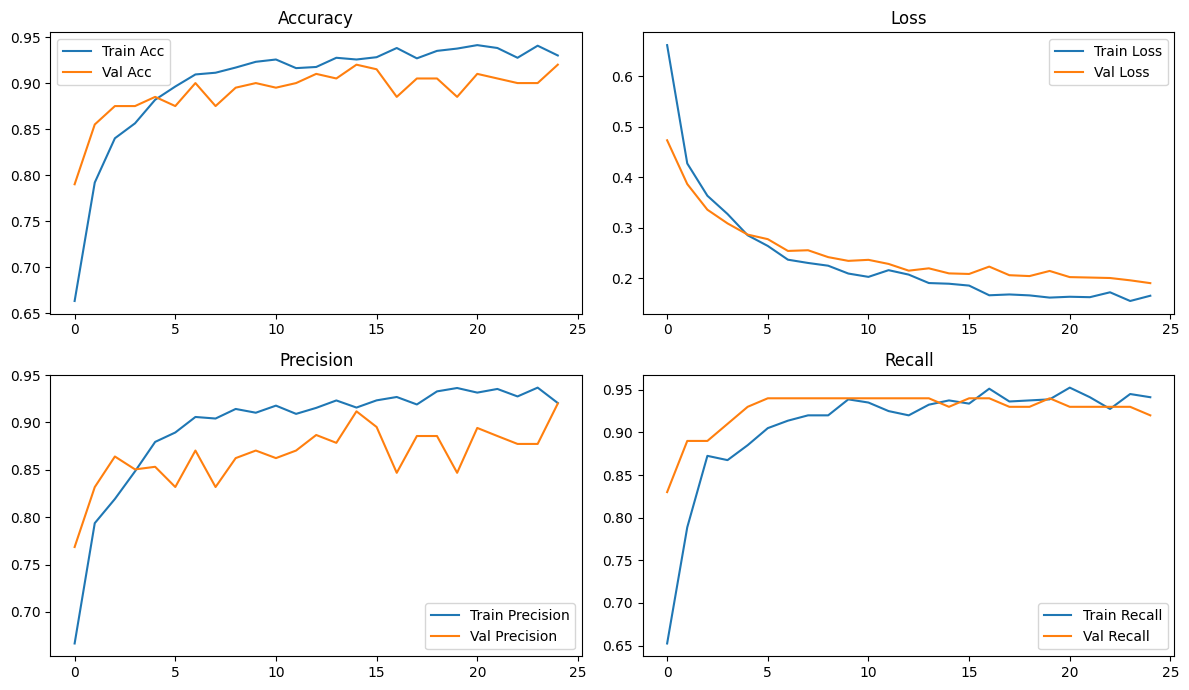

In [26]:
# Robust plot: handles precision/recall keys like precision_1
prec_key = next((k for k in history.history if "precision" in k and not k.startswith("val_")), None)
rec_key = next((k for k in history.history if "recall" in k and not k.startswith("val_")), None)

plt.figure(figsize=(12, 7))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(2, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# Precision
if prec_key:
    plt.subplot(2, 2, 3)
    plt.plot(history.history[prec_key], label="Train Precision")
    plt.plot(history.history[f"val_{prec_key}"], label="Val Precision")
    plt.legend()
    plt.title("Precision")

# Recall
if rec_key:
    plt.subplot(2, 2, 4)
    plt.plot(history.history[rec_key], label="Train Recall")
    plt.plot(history.history[f"val_{rec_key}"], label="Val Recall")
    plt.legend()
    plt.title("Recall")

plt.tight_layout()
plt.show()

In [27]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test Prec: {test_prec:.4f}")
print(f"Test Rec:  {test_rec:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9200 - loss: 0.2041 - precision_2: 0.9884 - recall_2: 0.8500   
Test Loss: 0.2041
Test Acc:  0.9200
Test Prec: 0.9884
Test Rec:  0.8500


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 452ms/step


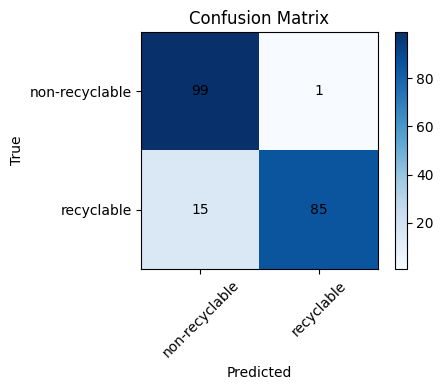

                precision    recall  f1-score   support

non-recyclable       0.87      0.99      0.93       100
    recyclable       0.99      0.85      0.91       100

      accuracy                           0.92       200
     macro avg       0.93      0.92      0.92       200
  weighted avg       0.93      0.92      0.92       200



In [29]:
# Collect ground-truth labels
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# Predict probabilities
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Class labels
class_names = ["non-recyclable", "recyclable"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

In [30]:
model.save("models/stage1_mobilenetv3.keras")